# Clase 2 — Selección de variables

**Maestría en Bioinformática y Biología de Sistemas — UNNOBA**
**Reconocimiento de Patrones en Bioinformática**

---

## Objetivos de esta clase

En la Clase 1 vimos que tirar miles de variables a un clasificador no funciona: la señal queda enterrada bajo el ruido. Hoy vamos a aprender a **elegir** las variables que importan.

Los objetivos de la clase son:

1. Distinguir las tres familias de selección: **filtros**, **wrappers** y **embedded**.
2. Aplicar **filtros univariados** con corrección por testeo múltiple (FDR).
3. Aplicar **wrappers** como Recursive Feature Elimination (RFE).
4. Aplicar métodos **embedded** (Lasso, importancia de Random Forest, Boruta).
5. Evaluar la **estabilidad** de una selección con bootstrap.
6. Reconocer cuándo la selección debe ir **dentro** del CV (data leakage, repaso de Clase 1).

## Cómo está organizada la clase

- **Bloque 1 :** Las tres familias de selección. Dataset de hoy.
- **Bloque 2 :** Filtros univariados y FDR. **Ejercicio 1.**
- **Bloque 3 :** Wrappers — RFE. **Ejercicio 2.**
- **Bloque 4 :** Embedded — Lasso e importancia RF. **Ejercicio 3.**
- **Bloque 5 :** Estabilidad de la selección. **Ejercicio 4.**
- **Cierre :** **Ejercicio 5** integrador.

In [15]:
# !pip install numpy pandas matplotlib seaborn scikit-learn scipy statsmodels --quiet

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Setup listo.")

Setup listo.


---

# Bloque 1 — Las tres familias de selección

## Por qué seleccionar variables

Tres razones, en orden de importancia:

1. **Performance:** vimos en Clase 1 que clasificadores como KNN se degradan cuando hay muchas variables irrelevantes. Random Forest y SVM también sufren, aunque menos.
2. **Interpretabilidad:** un modelo con 20 genes es comprensible biológicamente. Uno con 20.000 no.
3. **Reproducibilidad y costos:** un panel diagnóstico de 20 genes se puede llevar a un kit clínico. Uno de 20.000 no.

## Las tres familias
Cada familia ataca el problema desde un ángulo distinto. Conviene tener una idea clara de cómo trabaja cada una antes de aplicarlas.

**Filtros**: Evalúan cada variable por separado contra el target, usando algún criterio estadístico (test t, mutual information, etc.). No usan un modelo de clasificación: solo miden "qué tan informativa parece ser esta variable, mirada de a una por vez". Son los más rápidos porque cada variable se procesa de forma independiente del resto, pero por la misma razón ignoran interacciones: dos variables que individualmente parecen inútiles pero juntas separan las clases nunca son detectadas. Se usan típicamente como primer paso para descartar la mayor parte del ruido antes de aplicar algo más sofisticado.

**Wrappers**: Eligen subconjuntos de variables y evalúan cada subconjunto entrenando un modelo real. La idea es: si querés saber qué variables sirven para clasificar, probá clasificar con ellas. El más clásico es Recursive Feature Elimination (RFE): entrenás con todas, eliminás la menos importante según el modelo, reentrenás, repetís. Capturan interacciones (porque el modelo las ve), pero son caros (entrenás muchos modelos) y sensibles al modelo elegido: RFE con regresión logística puede dar variables muy distintas a RFE con SVM.

**Embedded**: La selección está integrada en el ajuste del modelo mismo. Cuando entrenás un Lasso, los coeficientes salen ya con muchos en cero exacto: el modelo "decidió" qué variables usar como parte de su optimización. Cuando entrenás un Random Forest, cada split de cada árbol elige qué variable usar según la ganancia de información, y al final podés mirar cuánto contribuyó cada variable en promedio. Son un compromiso razonable: menos caros que wrappers, capturan interacciones, pero la selección queda atada al modelo (cambiás de Lasso a Random Forest y obtenés otras variables).

| Familia | Cómo decide | Costo | Riesgo |
|---|---|---|---|
| **Filtros univariados** | Mira cada variable por separado (sin modelo) | Bajo | Ignora interacciones |
| **Wrappers** | Evalúa subconjuntos con un modelo real | Alto | Sobreajuste, lento |
| **Embedded** | La selección está integrada al modelo | Medio | Atado al modelo |

## El dataset de hoy

Vamos a usar un dataset simulado tipo **microarray**: 60 pacientes, 4000 genes, sólo 30 con señal real. Esto refleja un experimento bioinformático típico.

In [17]:
import numpy as np
# Dataset sintético controlado (tipo microarray)
rng = np.random.RandomState(42)
n = 60
p = 4000
n_informative = 30

# Ruido gaussiano para todas las variables
X = rng.randn(n, p)

# Etiquetas balanceadas
y = np.concatenate([np.zeros(30), np.ones(30)]).astype(int)
rng.shuffle(y)

# Las primeras n_informative tienen señal real, con effect size variable
# (entre 1.0 y 1.8 — moderado pero detectable)
effect_sizes = rng.uniform(1.0, 1.8, n_informative)
for j in range(n_informative):
    X[y == 1, j] += effect_sizes[j]

# La "verdad" — las variables informativas son las primeras n_informative
informativas_reales = set(range(n_informative))

print(f"Dataset: X = {X.shape}, y = {y.shape}")
print(f"Balance de clases: {np.bincount(y)}")
print(f"Variables verdaderamente informativas: {n_informative} de {p}")
print(f"(En la realidad no las conocemos — acá las guardamos para evaluar.)")

Dataset: X = (60, 4000), y = (60,)
Balance de clases: [30 30]
Variables verdaderamente informativas: 30 de 4000
(En la realidad no las conocemos — acá las guardamos para evaluar.)


**Observá la forma:** 60 × 4000. Es exactamente el régimen p ≫ n. En la próxima celda hacemos un train/test split que vamos a usar a lo largo de la clase.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape},  Test: {X_test.shape}")
print(f"Balance train: {np.bincount(y_train)},  Balance test: {np.bincount(y_test)}")

Train: (42, 4000),  Test: (18, 4000)
Balance train: [21 21],  Balance test: [9 9]


---

# Bloque 2 — Filtros univariados

Un **filtro univariado** evalúa cada variable **por separado** según un criterio estadístico. Es el método más rápido y el más usado en bioinformática como primer paso.

Criterios típicos:

| Criterio | Tipo de variable | Notas |
|---|---|---|
| Test t (o ANOVA F) | Continuas, clases | Asume normalidad aproximada |
| Mann-Whitney U | Continuas, clases | No paramétrico, robusto |
| Mutual Information | Cualquiera | Captura no linealidades |
| Chi-cuadrado | Conteos | Para datos discretos |


### Cuándo conviene cada uno:
#### Test t (y ANOVA F para más de dos clases):
 El más usado en bioinformática por costumbre histórica y por su velocidad. Compara las medias entre grupos relativizándolas a la varianza dentro de cada grupo. Asume aproximadamente normalidad en cada clase, pero es robusto a desviaciones moderadas. En la práctica con $n$ moderado funciona bien casi siempre. ANOVA F es la generalización para tres o más clases.
#### Mann-Whitney U (y Kruskal-Wallis para más de dos clases):
Compara las distribuciones de cada grupo sin suponer normalidad, trabajando con los rangos en lugar de los valores brutos. Útil cuando tenés outliers, distribuciones asimétricas o pocas muestras. Pierde algo de potencia respecto al t si las distribuciones son realmente normales, pero gana robustez. Es el default seguro para datos de RNA-seq antes de log-transformar.
#### Mutual Information:
Mide cuánta información sobre la clase aporta una variable, sin asumir una relación lineal o monótona. Si la relación entre el gen $j$ y la clase es no-lineal (por ejemplo, un valor intermedio es indicativo de la clase 1 y valores extremos de la clase 0), test t no lo detecta pero MI sí. Es más caro de calcular y necesita más muestras para ser confiable.
#### Chi-cuadrado:
Específicamente para datos de conteos o categóricos: tablas de contingencia, expresión binarizada, datos de SNPs (genotipos AA/Aa/aa), motivos presentes/ausentes. No conviene aplicarlo a datos continuos sin discretizar primero (agrupar en categorias / intervalos).

## Lo que vimos en Clase 1

Hacer 4000 tests t y declarar significativo todo lo que tenga $p < 0.05$ nos da ~200 falsos positivos. Por eso corregimos con **Benjamini-Hochberg (FDR)**.

## Filtro con FDR

In [19]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Test t por gen (vectorizado: un solo llamado para los 4000 genes)
# IMPORTANTE: usamos sólo el train para no espiar el test
_, pvals = ttest_ind(X_train[y_train == 0], X_train[y_train == 1], axis=0)

# Corrección BH para controlar FDR < 0.05
reject_bh, pvals_adj, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

print(f"Variables seleccionadas (FDR < 0.05): {reject_bh.sum()}")
seleccionadas = set(np.where(reject_bh)[0])
print(f"De ellas, REALMENTE informativas:    {len(seleccionadas & informativas_reales)}")
print(f"Falsos positivos:                    {len(seleccionadas - informativas_reales)}")

Variables seleccionadas (FDR < 0.05): 25
De ellas, REALMENTE informativas:    22
Falsos positivos:                    3


## Ejercicio 1 — Filtro y umbrales de FDR (8 min)

**Tu tarea:**

1. Aplicá BH con tres umbrales: FDR < 0.01, < 0.05 y < 0.10.
2. Para cada uno, contá cuántas variables selecciona y cuántas son verdaderamente informativas (la verdad está en `informativas_reales`).
3. Después de seleccionar variables con cada umbral, ajustá un clasificador simple (regresión logística) y evaluá en test.

¿Qué umbral te da mejor accuracy en test? ¿Coincide con el que tiene mejor balance TP/FP?

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# TU CÓDIGO ACÁ
umbrales = [0.01, 0.05, 0.10]

print(f"{'FDR':>6} | {'Seleccionadas':>13} | {'TP':>4} | {'FP':>4} | {'Acc test':>9}")
print("-" * 55)

for alpha in umbrales:
    # 1. Seleccionar variables con BH a este umbral
    # 2. Contar TP y FP (comparando con informativas_reales)
    # 3. Entrenar LogisticRegression(max_iter=1000) sobre X_train[:, selected]
    # 4. Reportar accuracy en X_test[:, selected]
    pass  # COMPLETÁ ACÁ

   FDR | Seleccionadas |   TP |   FP |  Acc test
-------------------------------------------------------


> ¿Es razonable elegir el FDR mirando el accuracy en test? ¿O eso ya es data leakage de otro tipo?

---

# Bloque 3 — Wrappers: RFE

Un **wrapper** envuelve un modelo y evalúa subconjuntos de variables según el rendimiento del modelo. A diferencia de los filtros, **considera interacciones** entre variables.

## Recursive Feature Elimination (RFE)

Idea: entrenar un modelo con todas las variables, eliminar la menos importante, reentrenar, repetir.

**Ventajas:** considera el contexto multivariado.

**Desventajas:** costoso, sobre todo con $p$ grande. Sensible al modelo elegido (ej: RFE con regresión logística puede dar resultados muy distintos a RFE con SVM).

## RFE en la práctica

Como con 4000 variables RFE sería muy lento, lo combinamos con un pre-filtro: primero quedamos con los mejores 500 por t-test, después corremos RFE.

In [21]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression

# Paso 1: pre-filtro (top 500 por F-score)
pre_filter = SelectKBest(f_classif, k=500)
X_train_pre = pre_filter.fit_transform(X_train, y_train)
print(f"Después del pre-filtro: {X_train_pre.shape}")

# Paso 2: RFE para llevar 500 a 30
rfe = RFE(
    estimator=LogisticRegression(max_iter=2000, solver="liblinear"),
    n_features_to_select=30,
    step=20,  # eliminar 20 variables por iteración (más rápido)
)
rfe.fit(X_train_pre, y_train)
print(f"RFE seleccionó {rfe.support_.sum()} variables")

Después del pre-filtro: (42, 500)
RFE seleccionó 30 variables


## Ejercicio 2 — RFE vs filtro (10 min)

**Tu tarea:**

a) Aplicá el pipeline pre-filtro + RFE de la celda anterior para terminar con **30 variables** (que es exactamente cuántas son verdaderamente informativas).

b) ¿Cuántas de las 30 elegidas por RFE coinciden con las verdaderamente informativas? Compará con el filtro BH a FDR < 0.05 (¿cuántas de las que BH selecciona son reales?).

c) Entrená una `LogisticRegression` con las variables que eligió RFE y evaluá en test.

> **Atención a un detalle clave de implementación:** RFE corre sobre las 500 variables que dejó el pre-filtro, no sobre las 4000 originales. Entonces los índices que devuelve RFE (rfe.support_) están en el espacio reducido de 500. Para identificar qué variables del dataset original fueron elegidas, hay que traducir esos índices: el pre-filtro guarda qué 500 variables originales sobrevivieron, y RFE marca cuáles de esas 500 quedan al final. La traducción es encadenar las dos selecciones.

In [22]:
# RFE trabaja sobre las 500 variables que sobrevivieron al pre-filtro.
# Para saber qué variables del dataset original (de 4000) fueron elegidas,
# encadenamos las dos selecciones:
#   pre_filter.get_support(indices=True) → índices originales de las 500
#   rfe.support_                          → cuáles de esas 500 sobreviven al RFE
# Al indexar el primer array con el segundo, obtenemos los índices originales finales.

seleccionadas_originales = pre_filter.get_support(indices=True)[rfe.support_]
print(f"Índices originales seleccionados por RFE: shape = {seleccionadas_originales.shape}")
print(f"Primeros 5: {seleccionadas_originales[:5]}")

# TU CÓDIGO ACÁ:
# 1. Contar cuántas de las 30 elegidas están en informativas_reales
# 2. Comparar con BH a FDR < 0.05
# 3. Entrenar LogReg y evaluar en test

Índices originales seleccionados por RFE: shape = (30,)
Primeros 5: [ 1  4 11 13 14]




# Bloque 4 — Métodos embedded

Un método **embedded** integra la selección al ajuste del modelo: en una sola pasada, el modelo decide qué variables usar y con qué peso. Los dos más usados en bioinformática:

| Método | Cómo selecciona |
|---|---|
| **Lasso** (regresión L1) | La penalización empuja coeficientes irrelevantes a cero exacto durante el ajuste |
| **Random Forest / Gradient Boosting Machine (GBM)** | Cada split elige una variable según la ganancia de pureza; al final, se promedia cuánto contribuyó cada una |

Lasso y los modelos regularizados los vamos a profundizar en la **Clase 4**. Por hoy lo usamos como herramienta de selección.
> Aclaración sobre regularización: Ridge (penalización L2) también es regularización, pero no es embedded de selección: encoge coeficientes hacia cero pero no los lleva a cero exacto, así que se queda con todas las variables. Elastic Net (L1+L2) sí selecciona, porque tiene componente L1. Ambos los vemos en Clase 4.
## Lasso para selección
Un modelo de regresión común busca los coeficientes $β_j$​ que minimizan el error de predicción. Lasso agrega un castigo extra a la función a minimizar: la suma de los valores absolutos de los coeficientes (penalización L1).

$$\text{minimizar} = \underbrace{\text{error de predicción}}_{\text{ajuste a los datos}} + \lambda \underbrace{\{\sum​|\beta_j​|\}}_{\text{castigo L1}}$$
El parámetro λ regula cuán fuerte es el castigo. La consecuencia geométrica de usar valor absoluto (y no cuadrado, como Ridge) es que la solución óptima tiende a tener muchos coeficientes exactamente en cero. Lasso, al ajustarse, decide por sí mismo qué variables son prescindibles y las elimina sin que nadie le diga. Esa es la selección embebida: ocurre durante el entrenamiento, no como un paso separado.

Dos detalles prácticos importantes:

1. Hay que estandarizar las variables antes. Si los genes tienen escalas muy distintas (uno con valores entre 0-1, otro entre 100-10000), el castigo L1 los pega distinto y el resultado es injusto. StandardScaler resuelve esto poniendo todas las variables con media 0 y desvío 1.
2. El parámetro C en sklearn es el inverso de $λ: C=1/λ$. Entonces C chico = más regularización = menos variables seleccionadas. C=0.1 es bastante regularizado; C=10 casi no regulariza. (Convención rara pero hay que conocerla.)

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Lasso requiere variables estandarizadas
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# LogisticRegression con penalización L1 (Lasso)
lasso = LogisticRegression(
    penalty="l1", solver="liblinear", C=0.1, max_iter=2000, random_state=0
)
lasso.fit(X_train_s, y_train)

# Las variables seleccionadas son las que tienen coeficiente != 0
sel_lasso = np.where(np.abs(lasso.coef_[0]) > 1e-8)[0]
print(f"Lasso seleccionó: {len(sel_lasso)} variables")
print(f"De ellas, realmente informativas: {sum(1 for i in sel_lasso if i in informativas_reales)}")

Lasso seleccionó: 7 variables
De ellas, realmente informativas: 7


Lasso prefiere quedarse con pocas variables y descartar el resto, incluso entre variables correlacionadas (de un grupo correlacionado elige una y descarta el resto, a veces arbitrariamente). Por eso el conteo de seleccionadas suele ser menor que en filtros: alta precisión, pero menor recall (nos perdemos TP).

## Importancia de Random Forest
Acá usamos la lógica al revés. Un Random Forest no descarta variables: las usa todas. Lo que hace es asignarle a cada una una medida de cuán importante fue para sus decisiones.

La idea: cada árbol del bosque, en cada split, elige una variable y un umbral que separan mejor las clases. La calidad de un split se mide con un criterio de pureza (típicamente Gini o entropía): un split bueno deja los nodos hijos más "puros" en términos de clase que el nodo padre. Cada vez que una variable se usa para un split, contribuye una cantidad proporcional a cuánto mejoró la pureza. Si sumás estas contribuciones a lo largo de todos los árboles y todos los splits del bosque, obtenés un score por variable: la importancia.

**Variables con importancia alta** → fueron elegidas frecuentemente para splits útiles → tienen señal real.

**Variables con importancia baja** → casi nunca fueron elegidas, o cuando lo fueron no aportaron mucho → probablemente ruido.

Para usar esto como selector, ordenás todas las variables por importancia y te quedás con las top-$k$. No hay un umbral natural como en Lasso (donde "coef = 0" ya define el corte), así que tenés que elegir $k$: o por conocimiento del problema ("queremos 30 genes"), o por validación cruzada, o por el "codo" del gráfico de importancias.

Dos cuidados con la importancia de RF:

1. No requiere estandarizar: los árboles son invariantes a la escala. Esto es una ventaja sobre Lasso.
2. El método nativo (Gini importance) tiene un sesgo conocido: tiende a favorecer variables con muchos valores únicos (continuas vs categóricas binarias). Para selección más rigurosa conviene usar permutation importance (lo vemos en Clase 6), pero la nativa de RF es un buen primer paso.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

importancias = rf.feature_importances_

# Top 30 por importancia
top30_rf = np.argsort(importancias)[::-1][:30]
print(f"Top 30 por importancia RF:")
print(f"  Realmente informativas en el top 30: {sum(1 for i in top30_rf if i in informativas_reales)}")

Top 30 por importancia RF:
  Realmente informativas en el top 30: 14


Random Forest, a diferencia de Lasso, tolera mejor las variables correlacionadas (las usa a todas con importancia repartida) y captura interacciones no lineales. Como contrapartida, su top-kk
k suele incluir más falsos positivos que Lasso: variables que aparecen "importantes" por sutilezas del modelo, no porque tengan señal real fuerte. Recall alto, precisión más baja.

## Ejercicio 3 — Comparar las tres familias (10 min)

**Tu tarea:**

Completá la tabla siguiente comparando filtro BH, RFE, Lasso e importancia RF sobre el mismo train/test:

| Método | # vars sel. | TP (de 30) | Accuracy test |
|---|---|---|---|

Para cada método: registrá el número de variables seleccionadas, cuántas son realmente informativas (TP), y el accuracy de una `LogisticRegression` entrenada con esas variables sobre el test.

**Pregunta:** ¿algún método domina a los otros, o cada uno tiene fortalezas distintas?

In [25]:
# TU CÓDIGO ACÁ
# Sugerencia: armá una función helper que reciba un array de índices seleccionados
# y devuelva (n_sel, tp, accuracy_test).

def evaluar_seleccion(indices, X_train, X_test, y_train, y_test, informativas):
    """
    Devuelve (n_seleccionadas, true_positives, accuracy_test).
    """
    n_sel = len(indices)
    tp = sum(1 for i in indices if i in informativas)
    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train[:, indices], y_train)
    acc = clf.score(X_test[:, indices], y_test)
    return n_sel, tp, acc

# Aplicá esta función a los cuatro métodos y armá la tabla

---

# Bloque 5 — Estabilidad de la selección

Hasta ahora elegimos variables sobre **un solo** train. Pero si el train cambia un poco (otros pacientes), ¿la selección es la misma?

Esto importa muchísimo en biomedicina: si publicás "los 30 genes que distinguen tumores", esos 30 deberían ser robustos. Si cambian con cada bootstrap, no son biomarcadores: son artefactos.

## Bootstrap para evaluar estabilidad

#### Significado de bootstrap
Bootstrap es una técnica de remuestreo que simula tener "datasets nuevos" a partir del que tenemos. La idea es muy simple:

> Si tenés un dataset con $n$ muestras, un bootstrap es una muestra aleatoria de tamaño $n$ tomada con reemplazo del dataset original.

Tres consecuencias importantes de ese "con reemplazo":

1. Algunas muestras del original aparecen varias veces en el bootstrap.
2. Otras muestras del original no aparecen ni una vez (en promedio, ~37% queda afuera de cada bootstrap).
3. El bootstrap tiene exactamente $n$ muestras, igual que el original, pero distinta composición.

Cada bootstrap es como si hubieras "reclutado un dataset parecido" a partir del mismo proceso que generó tus datos. Si repetís $B$ bootstraps (típicamente 50 a 500), tenés $B$ versiones ligeramente distintas del experimento.

**Utilidad para para evaluar estabilidad**: si una variable es realmente importante, debería aparecer seleccionada en la mayoría de los bootstraps. Si solo aparece en algunos, es porque su selección depende de qué pacientes específicos entraron en el entrenamiento, no de una señal robusta. Eso es exactamente lo que querés detectar.
Repetimos la selección sobre $B$ bootstraps del train y vemos qué tan frecuente es cada variable.

Aca les dejo un link con una explicacion que me gusta de bootstrap - <https://www.youtube.com/watch?v=Xz0x-8-cgaQ>

In [26]:
def seleccion_lasso(X, y, C=0.1):
    """Devuelve el conjunto de índices seleccionados por Lasso."""
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    clf = LogisticRegression(penalty="l1", solver="liblinear", C=C,
                             max_iter=2000, random_state=0)
    clf.fit(Xs, y)
    return set(np.where(np.abs(clf.coef_[0]) > 1e-8)[0])

# Bootstrap
B = 50
rng = np.random.RandomState(0)
n_train = len(X_train)

contador = np.zeros(p, dtype=int)
for b in range(B):
    idx = rng.randint(0, n_train, size=n_train)  # muestreo con reemplazo
    sel = seleccion_lasso(X_train[idx], y_train[idx])
    for i in sel:
        contador[i] += 1

frecuencia = contador / B
print(f"Variables que aparecen en >50% de los bootstraps: {(frecuencia > 0.5).sum()}")
print(f"Variables que aparecen en >80% de los bootstraps: {(frecuencia > 0.8).sum()}")

Variables que aparecen en >50% de los bootstraps: 3
Variables que aparecen en >80% de los bootstraps: 0


Cómo leer estos números:

- $frecuencia[i]$ es la fracción de bootstraps donde la variable ii
i fue seleccionada por Lasso (un número entre 0 y 1).
- Una variable que aparece en el 100% de los bootstraps (frecuencia = 1.0) es muy estable: Lasso la elige sin importar qué pacientes específicos haya en el train.
- Una variable que aparece en el 50% es dudosa: la mitad de las veces Lasso la considera útil, la otra mitad no. Probablemente es un artefacto del azar de qué pacientes entraron en cada bootstrap.
- El umbral del 60-80% es la zona típica donde se traza la línea de "firma estable" en publicaciones. No es un valor mágico, es una convención razonable.

Los dos números que imprimimos son una primera mirada al panorama: cuántas variables superan ciertos umbrales de robustez.

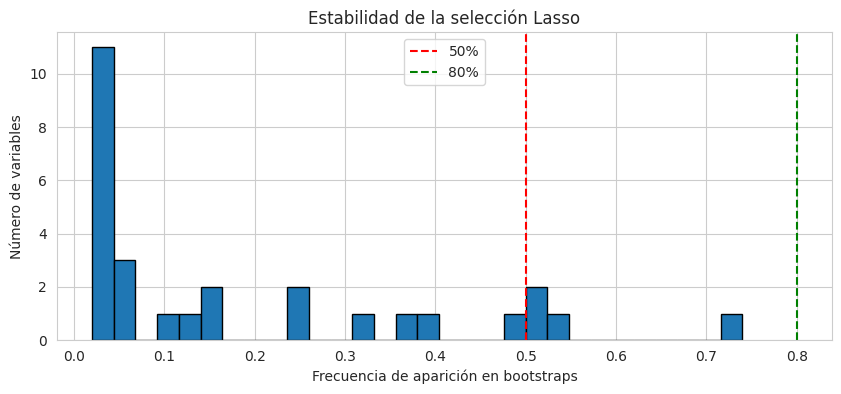

In [27]:
import matplotlib.pyplot as plt

# Visualizamos la distribución de frecuencias
plt.figure(figsize=(10, 4))
plt.hist(frecuencia[frecuencia > 0], bins=30, edgecolor="black")
plt.xlabel("Frecuencia de aparición en bootstraps")
plt.ylabel("Número de variables")
plt.title("Estabilidad de la selección Lasso")
plt.axvline(0.5, color="red", linestyle="--", label="50%")
plt.axvline(0.8, color="green", linestyle="--", label="80%")
plt.legend()
plt.show()

Cómo leer este gráfico:

- El eje x es la frecuencia de aparición de una variable en los bootstraps (0 a 1).
- El eje y es cuántas variables tienen esa frecuencia.
- Si Lasso fuera perfectamente estable, todas las variables informativas estarían cerca de 1 y todas las irrelevantes en 0: dos picos en los extremos.
- En la realidad vas a ver una cola larga hacia la izquierda: muchísimas variables apareciendo pocas veces (Lasso las eligió "por casualidad" en algún bootstrap puntual y nunca más). Eso es exactamente el problema de inestabilidad.
- Las variables a la derecha de la línea verde (>80%) son las que conviene reportar como "firma estable". Si esa zona está casi vacía, el dataset es difícil y conviene aflojar el umbral o sumar más muestras.

Nosotros vemos una distribución sesgada hacia frecuencias bajas, con apenas un puñado de variables superando el 50%. Esto es típico en bioinformática con nn
n chico: la mayoría de las "selecciones" son ruido. Por eso el bootstrap es indispensable: sin él, no podrías distinguir entre las pocas variables genuinamente útiles y el montón que aparecen una sola vez por suerte.

## Ejercicio 4 — Selección estable (10 min)

**Tu tarea:**

1. Definí como **"selección estable"** a las variables que aparecen en al menos el 60% de los bootstraps.
2. ¿Cuántas son? ¿Cuántas de esas son verdaderamente informativas?
3. Entrená una `LogisticRegression` con la **selección estable** y compará el accuracy en test contra el Lasso "de una sola pasada" del Bloque 4.

**Reflexión:** ¿gana o pierde performance una selección más conservadora?

In [28]:
# TU CÓDIGO ACÁ
umbral_estable = 0.6

# 1. Identificar variables estables
# 2. Comparar con informativas_reales
# 3. Entrenar y evaluar

## Data leakage
Sobre este vamos a profundizar en la última clase, pero que aparece naturalmente acá.
Data leakage es cuando información del conjunto de test (datos que se supone que el modelo "nunca vio") se filtra al proceso de entrenamiento. El resultado: la performance medida en test queda artificialmente inflada, y el modelo rinde mucho peor cuando lo aplicás a datos verdaderamente nuevos.
Cómo aparece el leakage en selección de variables:
Imaginá que tenés 60 pacientes y 4000 genes.

1. Aplicás filtro BH sobre los 60 pacientes y te quedás con los 25 mejores genes.
2. Hacés cross-validation con esos 25 genes para evaluar tu modelo.
3. Reportás "accuracy CV = 95%, mirá qué bien funcionan estos genes".

**El problema**: el filtro BH ya vio los 60 pacientes —incluyendo los que van a ser "test" en cada fold. Esos 25 genes fueron seleccionados porque separan bien a los 60 pacientes que conocés, no porque separen bien a pacientes nuevos. El CV mide la performance de un modelo que parte con una ventaja injusta: las variables ya están filtradas para funcionar en estos pacientes específicos.
**La forma correcta:**
La selección debe ir dentro del CV, no antes:

    para cada fold:
      train_fold, test_fold = split   
      aplicar BH sobre train_fold → genes_seleccionados
      entrenar modelo en train_fold[:, genes_seleccionados]
      evaluar en test_fold[:, genes_seleccionados]
    score honesto = promedio de los scores de cada fold

Cada fold selecciona sus propios genes, sin contaminarse con el test. El score resultante refleja lo que esperarías en pacientes verdaderamente nuevos.

En scikit-learn esto se hace metiendo la selección dentro de un Pipeline, que cross_val_score respeta automáticamente. Lo vemos en código en Clase 6.

**Regla general**: cualquier transformación que use información de la respuesta y (filtros, selección, oversampling) debe estar dentro del CV. Transformaciones que solo usan X (escalado, PCA) deberían también, aunque el daño es menor.

---

# Cierre — Ejercicio integrador

## Ejercicio 5 — Caso clínico (5 min, escrito)

Un grupo de investigación tiene **30 pacientes con cáncer de mama** (15 que responden a tratamiento y 15 que no). Midieron expresión de **25.000 genes**. Quieren identificar una **firma génica predictiva** de respuesta al tratamiento.

Diseñá un protocolo de selección de variables que tenga en cuenta lo que vimos hoy. Tu respuesta debería abordar:

1. ¿Qué tipo(s) de selección recomendás? ¿Por qué?
2. ¿Dónde tenés que tener cuidado con data leakage?
3. ¿Cómo evaluarías la estabilidad de tu firma?
4. ¿Qué les decís si insisten en publicar "los 30 genes elegidos por nuestro Lasso"?

**Tu respuesta:**

_(escribí acá tu protocolo en 5-8 líneas)_

---

## Resumen

| Concepto | Idea clave |
|---|---|
| **Filtros** | Rápidos. Buenos como primer paso. No ven interacciones. |
| **FDR (BH)** | Estándar en bioinformática. Mejor que Bonferroni para descubrimiento. |
| **Wrappers (RFE)** | Más caros. Ven interacciones. Sensibles al modelo subyacente. |
| **Embedded (Lasso, RF)** | Buen compromiso. Atados al modelo elegido. |
| **Estabilidad por bootstrap** | Una selección sólida debe aparecer consistentemente. |
| **Data leakage** | Toda selección que use y debe ir DENTRO del CV. |

## Conexión con la próxima clase

En la **Clase 3** vamos a abordar el problema desde otro ángulo: en vez de **seleccionar** variables, vamos a **proyectar** todo el espacio a una dimensión más baja (PCA, t-SNE, UMAP). Eso preserva información distribuida en muchas variables — útil cuando no hay un puñado claro de "variables clave".

---

*Bibliografía y videos en `bibliografia_clase2.md`.